## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

!pip install -q evaluate sacrebleu subword-nmt nltk pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.6 MB/s eta 0:00:00


In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
--2026-04-05 17:06:14--  https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12905334 (12M) [application/octet-stream]
Saving to: ‘data.txt’

data.txt            100%[===================>]  12.31M  --.-KB/s    in 0.04s   

2026-04-05 17:06:14 (281 MB/s) - ‘data.txt’ saved [12905334/12905334]



#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:

import os
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.tokenize import WordPunctTokenizer
import nltk
nltk.download('punkt')

import evaluate
metric = evaluate.load("sacrebleu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [4]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(path_do_data, sep="\t", header=None, names=["trg", "src"])

df = df.dropna()
df["src"] = df["src"].astype(str).str.strip()
df["trg"] = df["trg"].astype(str).str.strip()
df = df[(df["src"] != "") & (df["trg"] != "")]
df = df.drop_duplicates().reset_index(drop=True)

print("Размер датасета:", len(df))
print(df.head())

Размер датасета: 48225
                                                 trg  \
0  Cordelia Hotel is situated in Tbilisi, a 3-min...   
1  At Tupirmarka Lodge you will find a 24-hour fr...   
2  Featuring free WiFi in all areas, Naigao Xiaow...   
3  Each has a TV and a private bathroom with shower.   
4  Your room comes with air conditioning and sate...   

                                                 src  
0  Отель Cordelia расположен в Тбилиси, в 3 минут...  
1  В числе удобств лоджа Tupirmarka круглосуточна...  
2  Апартаменты Naigao Xiaowo расположены в городе...  
3  В вашем распоряжении также телевизор и собстве...  
4  Номер оснащен кондиционером и спутниковым теле...  


In [6]:
train_data, temp_data = train_test_split(df, test_size=0.20, random_state=42, shuffle=True)
valid_data, test_data = train_test_split(temp_data, test_size=0.25, random_state=42, shuffle=True)

print("Number of training examples: ", len(train_data))
print("Number of validation examples: ", len(valid_data))
print("Number of testing examples:", len(test_data))

Number of training examples:  38580
Number of validation examples:  7233
Number of testing examples: 2412


In [7]:
from collections import Counter

SPECIAL_TOKENS = ['<pad>', '<unk>', '<sos>', '<eos>']

def build_vocab_from_dataframe(df, text_column, tokenizer, min_freq=3):
    counter = Counter()

    for text in df[text_column].tolist():
        tokens = tokenizer(text)
        counter.update(tokens)

    vocab = {}
    itos = []

    for token in SPECIAL_TOKENS:
        vocab[token] = len(vocab)
        itos.append(token)

    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)
            itos.append(token)

    return vocab, itos, counter

SRC_vocab, SRC_itos, SRC_counter = build_vocab_from_dataframe(
    train_data, text_column="src", tokenizer=tokenize, min_freq=3
)

TRG_vocab, TRG_itos, TRG_counter = build_vocab_from_dataframe(
    train_data, text_column="trg", tokenizer=tokenize, min_freq=3
)

In [8]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC_vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG_vocab)}")

Unique tokens in source (ru) vocabulary: 9283
Unique tokens in target (en) vocabulary: 6700


Here are tokens from original (RU) corpus:

In [9]:
SRC_itos[::1000]

['<pad>',
 'многочисленных',
 'les',
 'ней',
 'известный',
 'аэроэкспресс',
 'баню',
 'изысканных',
 'кемера',
 'треккинг']

And from target (EN) corpus:

In [10]:
TRG_itos[::1000]

['<pad>', 'foot', 'imperiale', 'lua', 'etienne', 'classics', 'helsingborg']

And here is example from train dataset:

In [11]:
print(train_data.iloc[9].to_dict())

{'trg': 'The B&B’s interior features wood floors and large windows.', 'src': 'В этом отеле типа «постель и завтрак» установлены большие окна, а интерьер отделан деревом.'}


Let's check the length distributions:

Length distribution in Train data


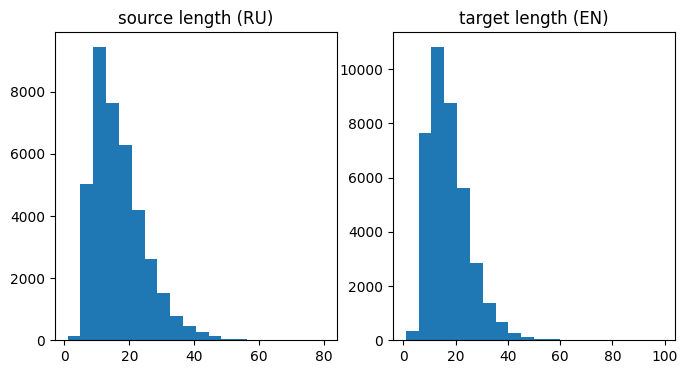

In [12]:
src_length = train_data["src"].apply(lambda x: len(tokenize(x)))
trg_length = train_data["trg"].apply(lambda x: len(tokenize(x)))

print("Length distribution in Train data")

plt.figure(figsize=[8, 4])

plt.subplot(1, 2, 1)
plt.title("source length (RU)")
plt.hist(src_length, bins=20)

plt.subplot(1, 2, 2)
plt.title("target length (EN)")
plt.hist(trg_length, bins=20)

plt.show()

распределение длин предложений в обучающей выборке для исходного русского текста и целевого английского перевода, распределения с правосторонней асимметрией. после основной массы коротких фраз естьдлинный, но малочисленный хвост более длинных последовательностей.

длины предложений на русском и английском языках в целом сопоставимы

Length distribution in Test data


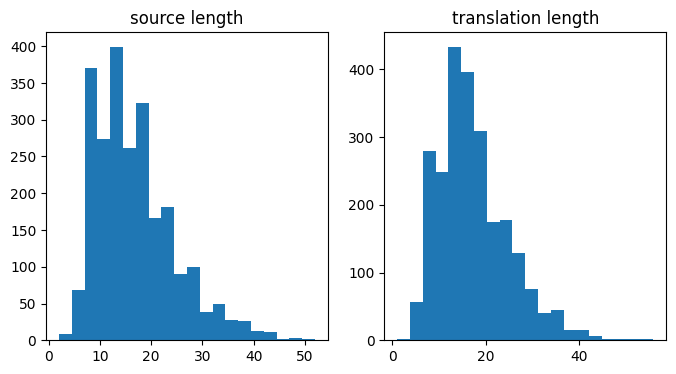

In [13]:
src_length = test_data["src"].apply(lambda x: len(tokenize(x)))
trg_length = test_data["trg"].apply(lambda x: len(tokenize(x)))

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])

plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(src_length, bins=20)

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(trg_length, bins=20)

plt.show()

распределение длин предложений в тестовой выборке для исходного русского текста и соответствующих английских переводов. основная масса наблюденй приходится на короткие и средние последовательности, тогда как длинные предложения встречаются сравнительно редко.

форма распределений в тестовой выборке в целом близка к распределениям в обучающей выборке.

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
device

device(type='cuda')

In [16]:
from torch.utils.data import Dataset, DataLoader

PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'

PAD_IDX_SRC = SRC_vocab[PAD_TOKEN]
UNK_IDX_SRC = SRC_vocab[UNK_TOKEN]
SOS_IDX_SRC = SRC_vocab[SOS_TOKEN]
EOS_IDX_SRC = SRC_vocab[EOS_TOKEN]

PAD_IDX_TRG = TRG_vocab[PAD_TOKEN]
UNK_IDX_TRG = TRG_vocab[UNK_TOKEN]
SOS_IDX_TRG = TRG_vocab[SOS_TOKEN]
EOS_IDX_TRG = TRG_vocab[EOS_TOKEN]


def encode_tokens(tokens, vocab, unk_idx):
    return [vocab.get(token, unk_idx) for token in tokens]


class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, trg_vocab, tokenizer):
        self.dataframe = dataframe.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        src_tokens = self.tokenizer(row["src"])
        trg_tokens = self.tokenizer(row["trg"])

        src_ids = [SOS_IDX_SRC] + encode_tokens(src_tokens, self.src_vocab, UNK_IDX_SRC) + [EOS_IDX_SRC]
        trg_ids = [SOS_IDX_TRG] + encode_tokens(trg_tokens, self.trg_vocab, UNK_IDX_TRG) + [EOS_IDX_TRG]

        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "trg_ids": torch.tensor(trg_ids, dtype=torch.long),
            "src_len": len(src_ids),
            "trg_len": len(trg_ids)
        }


def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x["src_len"], reverse=True)

    src_seqs = [item["src_ids"] for item in batch]
    trg_seqs = [item["trg_ids"] for item in batch]

    src_padded = nn.utils.rnn.pad_sequence(src_seqs, padding_value=PAD_IDX_SRC)
    trg_padded = nn.utils.rnn.pad_sequence(trg_seqs, padding_value=PAD_IDX_TRG)

    return src_padded.to(device), trg_padded.to(device)


BATCH_SIZE = 32

train_dataset = TranslationDataset(train_data, SRC_vocab, TRG_vocab, tokenize)
valid_dataset = TranslationDataset(valid_data, SRC_vocab, TRG_vocab, tokenize)
test_dataset = TranslationDataset(test_data, SRC_vocab, TRG_vocab, tokenize)

train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iterator = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_iterator)}")
print(f"Valid batches: {len(valid_iterator)}")
print(f"Test batches: {len(test_iterator)}")

Train batches: 1206
Valid batches: 227
Test batches: 76


In [17]:
for src_batch, trg_batch in train_iterator:
    break

print("Source batch:")
print(src_batch)
print("Target batch:")
print(trg_batch)

print(src_batch.shape, trg_batch.shape)

Source batch:
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [ 462,   10, 1704,  ...,   10, 1418,   10],
        [ 111, 1047, 5690,  ...,   43, 1101,  161],
        ...,
        [   1,   27,    0,  ...,    0,    0,    0],
        [  27,    3,    0,  ...,    0,    0,    0],
        [   3,    0,    0,  ...,    0,    0,    0]], device='cuda:0')
Target batch:
tensor([[  2,   2,   2,  ...,   2,   2,   2],
        [ 97, 340, 107,  ...,  29, 472,   4],
        [ 61, 842,  61,  ..., 385,  31, 140],
        ...,
        [ 16,   0, 168,  ...,   0,   0,   0],
        [  3,   0,  16,  ...,   0,   0,   0],
        [  0,   0,   3,  ...,   0,   0,   0]], device='cuda:0')
torch.Size([35, 32]) torch.Size([33, 32])


In [18]:
import torch
import torch.nn as nn
import random


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, src):
        embedded = self.embedding(src)
        embedded = self.dropout(embedded)
        output, (hidden, cell) = self.rnn(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.output_dim = output_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            num_embeddings=output_dim,
            embedding_dim=emb_dim
        )

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout
        )

        self.out = nn.Linear(
            in_features=hid_dim,
            out_features=output_dim
        )

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(0)

        embedded = self.dropout(self.embedding(input))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.out(output.squeeze(0))

        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):

        batch_size = trg.shape[1]
        max_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(max_len, batch_size, trg_vocab_size).to(self.device)

        hidden, cell = self.encoder(src)
        input = trg[0, :]

        for t in range(1, max_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.max(1)[1]
            input = trg[t] if teacher_force else top1

        return outputs

In [19]:
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)
ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 1
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.3

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [20]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9283, 128)
    (rnn): LSTM(128, 256, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(6700, 128)
    (rnn): LSTM(128, 256, dropout=0.3)
    (out): Linear(in_features=256, out_features=6700, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 4,558,252 trainable parameters


In [22]:
PAD_IDX = TRG_vocab['<pad>']
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [23]:
from IPython.display import clear_output

def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []

    for i, (src, trg) in enumerate(iterator):

        optimizer.zero_grad()

        output = model(src, trg)

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()
        history.append(loss.item())

        if (i + 1) % 20 == 0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

            clear_output(True)

            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title('Train loss')
            ax[0].legend()

            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')

            ax[1].set_title('General history')
            ax[1].legend()

            plt.tight_layout()
            plt.show()

    return epoch_loss / len(iterator)

In [24]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            output = model(src, trg, 0)

            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

            if (i + 1) % 20 == 0:
                print(f'Validation batch {i+1}/{len(iterator)} | loss = {loss.item():.3f}')

    return epoch_loss / len(iterator)

In [25]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [26]:
train_history = []
valid_history = []

N_EPOCHS = 5
CLIP = 1

best_valid_loss = float('inf')

In [27]:
from IPython.display import clear_output

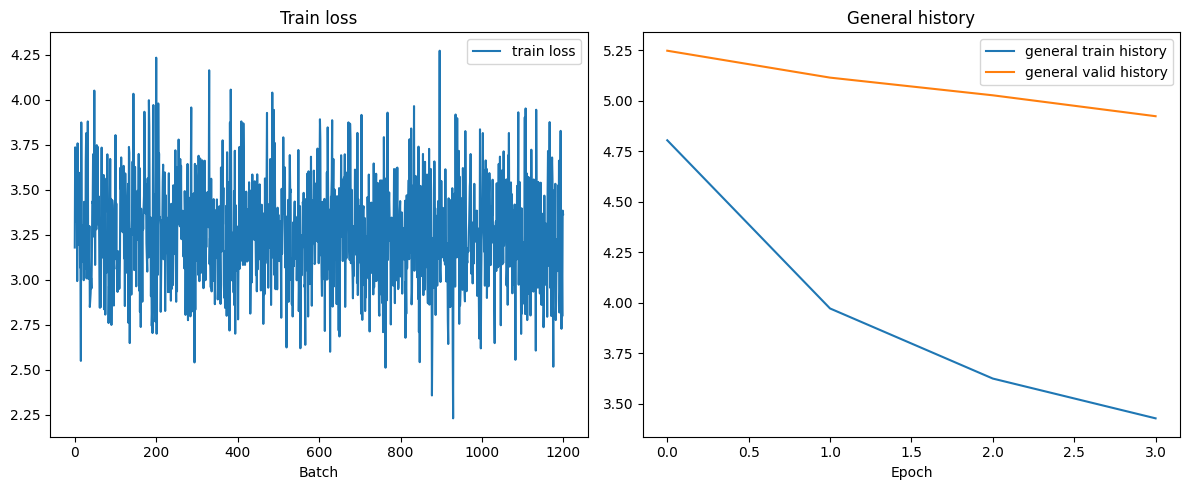

Validation batch 20/227 | loss = 4.881
Validation batch 40/227 | loss = 4.485
Validation batch 60/227 | loss = 5.255
Validation batch 80/227 | loss = 4.996
Validation batch 100/227 | loss = 4.709
Validation batch 120/227 | loss = 4.436
Validation batch 140/227 | loss = 5.154
Validation batch 160/227 | loss = 4.768
Validation batch 180/227 | loss = 4.962
Validation batch 200/227 | loss = 5.035
Validation batch 220/227 | loss = 5.053
Epoch: 05 | Time: 1m 59s
	Train Loss: 3.259 | Train PPL:  26.031
	 Val. Loss: 4.829 |  Val. PPL: 125.086


In [28]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

Видно снижение ошибки на обучающей выборке. `Train Loss` уменьшился с 4.80 до 3.26. Валидационная ошибкаснизилась с 5.25 до 4.83.  baseline-модель обучается и улучшает качество перевода

__Let's take a look at our network quality__:

In [29]:
batch = next(iter(test_iterator))

In [30]:
def ids_to_tokens(ids, itos, pad_token='<pad>', sos_token='<sos>', eos_token='<eos>'):
    tokens = []
    for idx in ids:
        token = itos[idx]
        if token == eos_token:
            break
        if token not in [pad_token, sos_token]:
            tokens.append(token)
    return tokens


def generate_translation(src, trg, model, src_itos, trg_itos):
    model.eval()

    with torch.no_grad():
        output = model(src, trg, 0)

    pred_ids = output.argmax(dim=-1).squeeze(1).cpu().numpy()
    src_ids = src.squeeze(1).cpu().numpy()
    trg_ids = trg.squeeze(1).cpu().numpy()

    src_tokens = ids_to_tokens(src_ids, src_itos)
    trg_tokens = ids_to_tokens(trg_ids, trg_itos)
    pred_tokens = ids_to_tokens(pred_ids, trg_itos)

    print("SRC :", " ".join(src_tokens))
    print("TRG :", " ".join(trg_tokens))
    print("PRED:", " ".join(pred_tokens))
    print("-" * 80)

In [31]:
src_batch, trg_batch = batch

for idx in [1, 2]:
    src = src_batch[:, idx:idx+1]
    trg = trg_batch[:, idx:idx+1]
    generate_translation(src, trg, model, SRC_itos, TRG_itos)

SRC : комплекс домов на колесах <unk> apartments находится в окружении зелени в 40 м от пляжа и в 1 , 5 км от центра города <unk> , к вашим услугам кондиционированные дома на колесах , бесплатным wifi в зонах общественного пользования и бесплатная частная парковка .
TRG : surrounded by greenery 40 metres from a beach and 1 . 5 km from the centre of <unk> , <unk> apartments mobile homes offers air - conditioned accommodation with free wi - fi in public areas and free private parking .
PRED: located in the , of <unk> , , km from the <unk> , , this apartment features free wifi and free wifi access is available in the areas of the <unk> is free private parking is available on site .
--------------------------------------------------------------------------------
SRC : сотрудники гостевого дома будут рады более <unk> <unk> о мероприятиях на открытом воздухе , которые проводятся в окрестностях . кроме того , в гостевом доме можно приобрести билеты в природный парк <unk> , что в 13 км .
TRG :

baseline-модель воспроизводит общий шаблон перевода и частично передаёт  содержание, но остаётся низким. модель теряет важные детали, часто повторяет одни и те же конструкции и плохо справляется с редкими словами(`<unk>`).

In [32]:
def tokens_to_text(ids, itos, pad_token='<pad>', sos_token='<sos>', eos_token='<eos>'):
    tokens = []
    for idx in ids:
        token = itos[idx]
        if token == eos_token:
            break
        if token not in [pad_token, sos_token]:
            tokens.append(token)
    return " ".join(tokens)


def compute_bleu_on_iterator(model, iterator, src_itos, trg_itos, metric, max_batches=None):
    model.eval()

    predictions = []
    references = []

    with torch.no_grad():
        for batch_idx, (src, trg) in enumerate(iterator):
            output = model(src, trg, 0)

            pred_ids = output.argmax(dim=-1).cpu().numpy().T
            trg_ids = trg.cpu().numpy().T

            for pred_seq, true_seq in zip(pred_ids, trg_ids):
                pred_text = tokens_to_text(pred_seq, trg_itos)
                true_text = tokens_to_text(true_seq, trg_itos)

                predictions.append(pred_text)
                references.append([true_text])

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    bleu_result = metric.compute(predictions=predictions, references=references)
    return bleu_result, predictions, references

In [33]:
bleu_result, predictions, references = compute_bleu_on_iterator(
    model, test_iterator, SRC_itos, TRG_itos, metric, max_batches=30
)

print(bleu_result)

{'score': 17.492784916082247, 'counts': [8618, 4039, 2238, 1115], 'totals': [18925, 17965, 17005, 16045], 'precisions': [45.53764861294584, 22.482605065404954, 13.160835048515143, 6.949205359925211], 'bp': 1.0, 'sys_len': 18925, 'ref_len': 18290}


In [34]:
bleu_result, predictions, references = compute_bleu_on_iterator(
    model, test_iterator, SRC_itos, TRG_itos, metric
)

print("Test BLEU:", round(bleu_result["score"], 2))

Test BLEU: 17.93


После увеличения числа эпох качество baseline-модели улучшилось с **12.77** до **17.93**. базовая seq2seq-модель еще не исчерпала потенциал обучениня. Но
 после такого дообучения результат остается ниже порога

In [35]:
baseline_bleu = 17.93
baseline_train_history = train_history.copy()
baseline_valid_history = valid_history.copy()

In [36]:
# модель внимания
import torch
import torch.nn as nn
import random


class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.hid_dim = hid_dim

    def forward(self, hidden, encoder_outputs):

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        hidden = hidden.unsqueeze(1)

        energy = torch.sum(hidden * encoder_outputs, dim=2)
        attention = torch.softmax(energy, dim=1)

        return attention


class EncoderAttn(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)


        return outputs, hidden, cell


class DecoderAttn(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()

        self.output_dim = output_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.rnn = nn.LSTM(
            input_size=emb_dim + hid_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):

        input = input.unsqueeze(0)

        embedded = self.dropout(self.embedding(input))

        attn_weights = self.attention(hidden[-1], encoder_outputs)

        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs_perm)
        context = context.permute(1, 0, 2)

        rnn_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction = self.fc_out(
            torch.cat(
                (output.squeeze(0), context.squeeze(0), embedded.squeeze(0)),
                dim=1
            )
        )

        return prediction, hidden, cell, attn_weights


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim
        assert encoder.n_layers == decoder.n_layers

    def forward(self, src, trg, teacher_forcing_ratio=0.5):

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input = trg[0, :]

        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

In [37]:
# инициализация
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)

ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 1
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.3

attn = Attention(HID_DIM)
enc_attn = EncoderAttn(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec_attn = DecoderAttn(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)

model_attn = Seq2SeqAttn(enc_attn, dec_attn, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        if param.requires_grad:
            nn.init.uniform_(param.data, -0.08, 0.08)

model_attn.apply(init_weights)

PAD_IDX = TRG_vocab['<pad>']
optimizer_attn = optim.Adam(model_attn.parameters())
criterion_attn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f'The attention model has {count_parameters(model_attn):,} trainable parameters')

The attention model has 7,393,196 trainable parameters


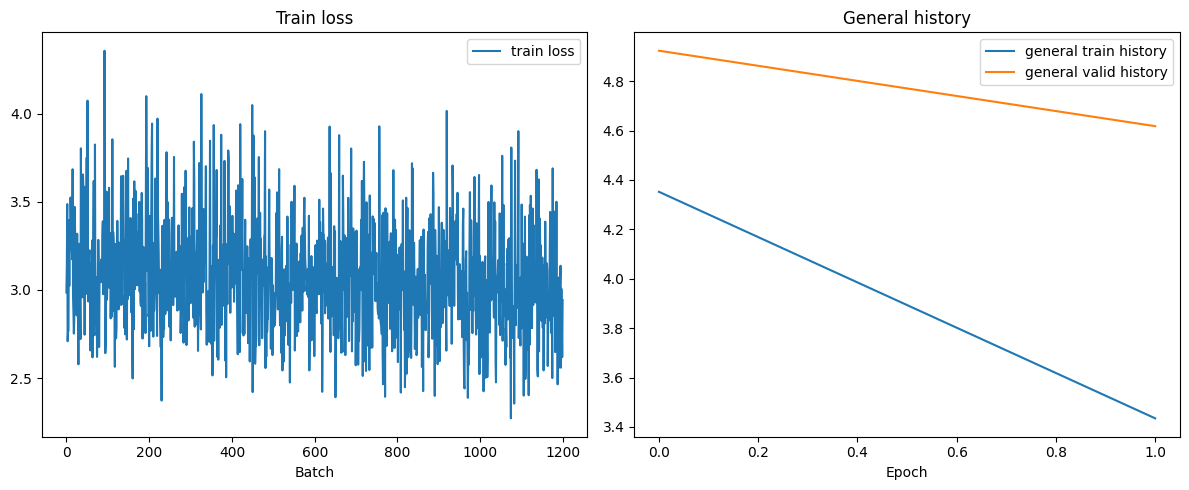

Validation batch 20/227 | loss = 4.713
Validation batch 40/227 | loss = 4.342
Validation batch 60/227 | loss = 5.070
Validation batch 80/227 | loss = 4.552
Validation batch 100/227 | loss = 4.527
Validation batch 120/227 | loss = 4.321
Validation batch 140/227 | loss = 4.600
Validation batch 160/227 | loss = 4.597
Validation batch 180/227 | loss = 5.021
Validation batch 200/227 | loss = 4.722
Validation batch 220/227 | loss = 4.806
Epoch: 03 | Time: 2m 36s
	Train Loss: 3.071 | Train PPL:  21.568
	 Val. Loss: 4.572 |  Val. PPL:  96.774


In [38]:
# обучение
train_history_attn = []
valid_history_attn = []

N_EPOCHS = 3
CLIP = 1

best_valid_loss_attn = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model_attn,
        train_iterator,
        optimizer_attn,
        criterion_attn,
        CLIP,
        train_history_attn,
        valid_history_attn
    )

    valid_loss = evaluate(model_attn, valid_iterator, criterion_attn)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss_attn:
        best_valid_loss_attn = valid_loss
        torch.save(model_attn.state_dict(), 'attention-model.pt')

    train_history_attn.append(train_loss)
    valid_history_attn.append(valid_loss)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

ошибка на обучающей выборке продолжила снижаться, а валидационная ошибка уменьшилась до 4.57. добавленное улучшение действительно повысило качество обучения и обобщающую способность модели. При этом разрыв между train и valid всё ещё сохраняется, поэтому потенциал для дальнейшего улучшения остаётся.

In [39]:
bleu_result_attn, predictions_attn, references_attn = compute_bleu_on_iterator(
    model_attn, test_iterator, SRC_itos, TRG_itos, metric
)

print("Attention Test BLEU:", round(bleu_result_attn["score"], 2))

Attention Test BLEU: 25.02


Модель с attention показала значение **BLEU = 25.02** на тестовой выборке. По сравнению с baseline это существенное улучшение качества перевода: модель не только лучше обучается по значениям функции потерь, но и заметно точнее воспроизводит целевые переводы на тесте.

BPE

In [40]:
import io

train_src_lines = train_data["src"].astype(str).tolist()
train_trg_lines = train_data["trg"].astype(str).tolist()

with open("train_src.txt", "w", encoding="utf-8") as f:
    for line in train_src_lines:
        f.write(line.strip() + "\n")

with open("train_trg.txt", "w", encoding="utf-8") as f:
    for line in train_trg_lines:
        f.write(line.strip() + "\n")

In [41]:
# обучение
from subword_nmt.learn_bpe import learn_bpe

BPE_OPS = 8000

with open("train_src.txt", "r", encoding="utf-8") as src_in, \
     open("bpe_src.codes", "w", encoding="utf-8") as src_codes:
    learn_bpe(src_in, src_codes, num_symbols=BPE_OPS)

with open("train_trg.txt", "r", encoding="utf-8") as trg_in, \
     open("bpe_trg.codes", "w", encoding="utf-8") as trg_codes:
    learn_bpe(trg_in, trg_codes, num_symbols=BPE_OPS)

100%|██████████| 8000/8000 [00:07<00:00, 1023.74it/s]


In [42]:
# BPE-токенизаторы
from subword_nmt.apply_bpe import BPE

bpe_src = BPE(open("bpe_src.codes", encoding="utf-8"))
bpe_trg = BPE(open("bpe_trg.codes", encoding="utf-8"))

def tokenize_bpe_src(text):
    return bpe_src.process_line(text.strip()).split()

def tokenize_bpe_trg(text):
    return bpe_trg.process_line(text.strip()).split()

In [43]:
example_text = train_data.iloc[0]["src"]
print("Original:", example_text)
print("BPE:", tokenize_bpe_src(example_text))

Original: Мемориальный комплекс "Мамаев курган" с монументом "Родина-мать зовет!" расположен в 3 остановках на скоростном трамвае от гостиницы "Финанс-Юг".
BPE: ['Мемо@@', 'риаль@@', 'ный', 'комплекс', '"@@', 'Ма@@', 'ма@@', 'ев', 'кур@@', 'ган@@', '"', 'с', 'мо@@', 'нумен@@', 'том', '"@@', 'Ро@@', 'ди@@', 'на-@@', 'м@@', 'ать', 'зо@@', 'вет@@', '!@@', '"', 'расположен', 'в', '3', 'останов@@', 'ках', 'на', 'скорост@@', 'ном', 'трамва@@', 'е', 'от', 'гостиницы', '"@@', 'Фи@@', 'на@@', 'нс@@', '-@@', 'Ю@@', 'г@@', '".']


длинные, редкие и составные слова разбиваются на более мелкие единицы.

In [44]:
# новые словари
SRC_vocab_bpe, SRC_itos_bpe, SRC_counter_bpe = build_vocab_from_dataframe(
    train_data, text_column="src", tokenizer=tokenize_bpe_src, min_freq=2
)

TRG_vocab_bpe, TRG_itos_bpe, TRG_counter_bpe = build_vocab_from_dataframe(
    train_data, text_column="trg", tokenizer=tokenize_bpe_trg, min_freq=2
)

print(f"Unique BPE tokens in source vocabulary: {len(SRC_vocab_bpe)}")
print(f"Unique BPE tokens in target vocabulary: {len(TRG_vocab_bpe)}")


Unique BPE tokens in source vocabulary: 8025
Unique BPE tokens in target vocabulary: 7898


In [45]:
# Dataset под BPE
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'

PAD_IDX_SRC_BPE = SRC_vocab_bpe[PAD_TOKEN]
UNK_IDX_SRC_BPE = SRC_vocab_bpe[UNK_TOKEN]
SOS_IDX_SRC_BPE = SRC_vocab_bpe[SOS_TOKEN]
EOS_IDX_SRC_BPE = SRC_vocab_bpe[EOS_TOKEN]

PAD_IDX_TRG_BPE = TRG_vocab_bpe[PAD_TOKEN]
UNK_IDX_TRG_BPE = TRG_vocab_bpe[UNK_TOKEN]
SOS_IDX_TRG_BPE = TRG_vocab_bpe[SOS_TOKEN]
EOS_IDX_TRG_BPE = TRG_vocab_bpe[EOS_TOKEN]


class TranslationDatasetBPE(Dataset):
    def __init__(self, dataframe, src_vocab, trg_vocab):
        self.dataframe = dataframe.reset_index(drop=True)
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        src_tokens = tokenize_bpe_src(row["src"])
        trg_tokens = tokenize_bpe_trg(row["trg"])

        src_ids = [SOS_IDX_SRC_BPE] + encode_tokens(src_tokens, self.src_vocab, UNK_IDX_SRC_BPE) + [EOS_IDX_SRC_BPE]
        trg_ids = [SOS_IDX_TRG_BPE] + encode_tokens(trg_tokens, self.trg_vocab, UNK_IDX_TRG_BPE) + [EOS_IDX_TRG_BPE]

        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "trg_ids": torch.tensor(trg_ids, dtype=torch.long),
            "src_len": len(src_ids),
            "trg_len": len(trg_ids)
        }


def collate_fn_bpe(batch):
    batch = sorted(batch, key=lambda x: x["src_len"], reverse=True)

    src_seqs = [item["src_ids"] for item in batch]
    trg_seqs = [item["trg_ids"] for item in batch]

    src_padded = nn.utils.rnn.pad_sequence(src_seqs, padding_value=PAD_IDX_SRC_BPE)
    trg_padded = nn.utils.rnn.pad_sequence(trg_seqs, padding_value=PAD_IDX_TRG_BPE)

    return src_padded.to(device), trg_padded.to(device)

In [46]:
# DataLoader для BPE
BATCH_SIZE = 32

train_dataset_bpe = TranslationDatasetBPE(train_data, SRC_vocab_bpe, TRG_vocab_bpe)
valid_dataset_bpe = TranslationDatasetBPE(valid_data, SRC_vocab_bpe, TRG_vocab_bpe)
test_dataset_bpe = TranslationDatasetBPE(test_data, SRC_vocab_bpe, TRG_vocab_bpe)

train_iterator_bpe = DataLoader(train_dataset_bpe, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_bpe)
valid_iterator_bpe = DataLoader(valid_dataset_bpe, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_bpe)
test_iterator_bpe = DataLoader(test_dataset_bpe, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_bpe)

print(f"Train batches: {len(train_iterator_bpe)}")
print(f"Valid batches: {len(valid_iterator_bpe)}")
print(f"Test batches: {len(test_iterator_bpe)}")

Train batches: 1206
Valid batches: 227
Test batches: 76


In [47]:
# Attention-модель на BPE
INPUT_DIM_BPE = len(SRC_vocab_bpe)
OUTPUT_DIM_BPE = len(TRG_vocab_bpe)

ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 1
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.3

attn_bpe = Attention(HID_DIM)
enc_bpe = EncoderAttn(INPUT_DIM_BPE, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec_bpe = DecoderAttn(OUTPUT_DIM_BPE, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn_bpe)

model_bpe = Seq2SeqAttn(enc_bpe, dec_bpe, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        if param.requires_grad:
            nn.init.uniform_(param.data, -0.08, 0.08)

model_bpe.apply(init_weights)

PAD_IDX_BPE = TRG_vocab_bpe['<pad>']
optimizer_bpe = optim.Adam(model_bpe.parameters())
criterion_bpe = nn.CrossEntropyLoss(ignore_index=PAD_IDX_BPE)

print(f'The BPE attention model has {count_parameters(model_bpe):,} trainable parameters')

The BPE attention model has 8,153,434 trainable parameters


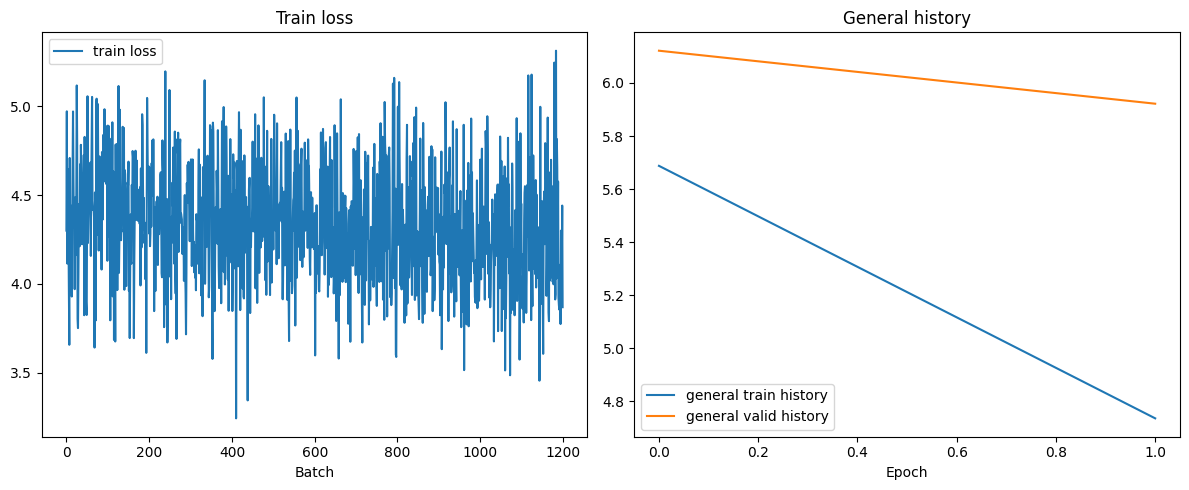

Validation batch 20/227 | loss = 5.720
Validation batch 40/227 | loss = 5.663
Validation batch 60/227 | loss = 6.387
Validation batch 80/227 | loss = 5.949
Validation batch 100/227 | loss = 6.025
Validation batch 120/227 | loss = 5.441
Validation batch 140/227 | loss = 6.206
Validation batch 160/227 | loss = 5.797
Validation batch 180/227 | loss = 5.953
Validation batch 200/227 | loss = 6.309
Validation batch 220/227 | loss = 5.966
Epoch: 03 | Time: 3m 10s
	Train Loss: 4.335 | Train PPL:  76.327
	 Val. Loss: 5.765 |  Val. PPL: 318.958


In [48]:
# обучение
train_history_bpe = []
valid_history_bpe = []

N_EPOCHS = 3
CLIP = 1

best_valid_loss_bpe = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model_bpe,
        train_iterator_bpe,
        optimizer_bpe,
        criterion_bpe,
        CLIP,
        train_history_bpe,
        valid_history_bpe
    )

    valid_loss = evaluate(model_bpe, valid_iterator_bpe, criterion_bpe)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss_bpe:
        best_valid_loss_bpe = valid_loss
        torch.save(model_bpe.state_dict(), 'bpe-attention-model.pt')

    train_history_bpe.append(train_loss)
    valid_history_bpe.append(valid_loss)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

In [49]:
bleu_result_bpe, predictions_bpe, references_bpe = compute_bleu_on_iterator(
    model_bpe, test_iterator_bpe, SRC_itos_bpe, TRG_itos_bpe, metric
)

print("BPE Attention Test BLEU:", round(bleu_result_bpe["score"], 2))

BPE Attention Test BLEU: 9.37


Модель с attention и BPE показала значение **BLEU = 9.37**, что хуже результата attention-модели без BPE. выбранная настройка subword-пайплайна не дала ожидаемого улучшения. попробуем улучшить результат

In [50]:
# функция обратной сборки
def decode_bpe_text(text):
    return text.replace('@@ ', '').replace('@@', '')

In [51]:
# BLUE for BPE
def compute_bleu_on_iterator_bpe(model, iterator, trg_itos, metric):
    model.eval()

    predictions = []
    references = []

    with torch.no_grad():
        for src, trg in iterator:
            output = model(src, trg, 0)

            pred_ids = output.argmax(dim=-1).cpu().numpy().T
            trg_ids = trg.cpu().numpy().T

            for pred_seq, true_seq in zip(pred_ids, trg_ids):
                pred_text = tokens_to_text(pred_seq, trg_itos)
                true_text = tokens_to_text(true_seq, trg_itos)

                pred_text = decode_bpe_text(pred_text)
                true_text = decode_bpe_text(true_text)

                predictions.append(pred_text)
                references.append([true_text])

    bleu_result = metric.compute(predictions=predictions, references=references)
    return bleu_result, predictions, references

In [52]:
bleu_result_bpe_fixed, predictions_bpe_fixed, references_bpe_fixed = compute_bleu_on_iterator_bpe(
    model_bpe, test_iterator_bpe, TRG_itos_bpe, metric
)

print("BPE Attention Test BLEU (fixed):", round(bleu_result_bpe_fixed["score"], 2))

BPE Attention Test BLEU (fixed): 15.18


Наиболее эффективным улучшением оказался механизм attention. эта модификация дала максимальный показатель **25.02 BLEU** на тестовой выборке. Использование BPE в текущей конфигурации ухудшило результат

bidirectional encoder + attention

In [53]:
class EncoderBiAttn(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, emb_dim)

        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=True
        )

        self.fc_hidden = nn.Linear(hid_dim * 2, hid_dim)
        self.fc_cell = nn.Linear(hid_dim * 2, hid_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))

        outputs, (hidden, cell) = self.rnn(embedded)

        batch_size = src.shape[1]

        hidden = hidden.view(self.n_layers, 2, batch_size, self.hid_dim)
        cell = cell.view(self.n_layers, 2, batch_size, self.hid_dim)

        hidden_cat = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        cell_cat = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

        hidden = torch.tanh(self.fc_hidden(hidden_cat))
        cell = torch.tanh(self.fc_cell(cell_cat))

        return outputs, hidden, cell

In [54]:
class AttentionBi(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [55]:
# декодер
class DecoderBiAttn(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()

        self.output_dim = output_dim
        self.emb_dim = emb_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.rnn = nn.LSTM(
            input_size=emb_dim + hid_dim * 2,
            hidden_size=hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hid_dim + hid_dim * 2 + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        input = input.unsqueeze(0)

        embedded = self.dropout(self.embedding(input))

        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)

        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs_perm)
        context = context.permute(1, 0, 2)

        rnn_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction = self.fc_out(
            torch.cat((output.squeeze(0), context.squeeze(0), embedded.squeeze(0)), dim=1)
        )

        return prediction, hidden, cell, a.squeeze(1)

In [56]:
# Seq2Seq-класс
class Seq2SeqBiAttn(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim
        assert encoder.n_layers == decoder.n_layers

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input = trg[0, :]

        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

In [57]:
# инициализация
INPUT_DIM = len(SRC_vocab)
OUTPUT_DIM = len(TRG_vocab)

ENC_EMB_DIM = 128
DEC_EMB_DIM = 128
HID_DIM = 256
N_LAYERS = 1
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.3

attn_bi = AttentionBi(HID_DIM)
enc_bi = EncoderBiAttn(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec_bi = DecoderBiAttn(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn_bi)

model_bi = Seq2SeqBiAttn(enc_bi, dec_bi, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        if param.requires_grad:
            nn.init.uniform_(param.data, -0.08, 0.08)

model_bi.apply(init_weights)

PAD_IDX = TRG_vocab['<pad>']
optimizer_bi = optim.Adam(model_bi.parameters())
criterion_bi = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f'The bidirectional attention model has {count_parameters(model_bi):,} trainable parameters')

The bidirectional attention model has 10,225,580 trainable parameters


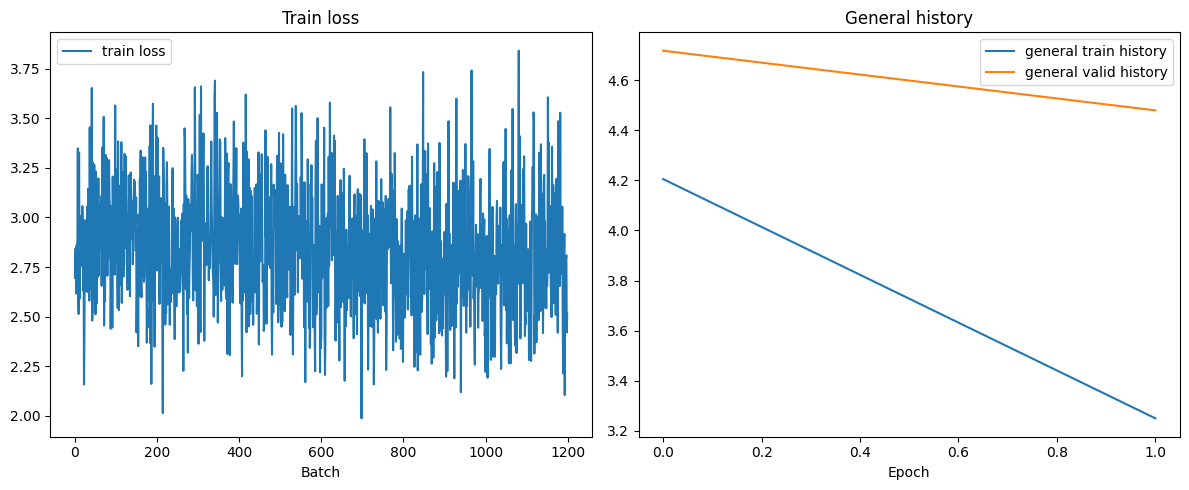

Validation batch 20/227 | loss = 4.485
Validation batch 40/227 | loss = 4.294
Validation batch 60/227 | loss = 5.041
Validation batch 80/227 | loss = 4.364
Validation batch 100/227 | loss = 4.329
Validation batch 120/227 | loss = 4.201
Validation batch 140/227 | loss = 4.501
Validation batch 160/227 | loss = 4.459
Validation batch 180/227 | loss = 4.865
Validation batch 200/227 | loss = 4.572
Validation batch 220/227 | loss = 4.479
Epoch: 03 | Time: 3m 12s
	Train Loss: 2.838 | Train PPL:  17.078
	 Val. Loss: 4.381 |  Val. PPL:  79.931


In [58]:
# обучение
train_history_bi = []
valid_history_bi = []

N_EPOCHS = 3
CLIP = 1

best_valid_loss_bi = float('inf')

for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(
        model_bi,
        train_iterator,
        optimizer_bi,
        criterion_bi,
        CLIP,
        train_history_bi,
        valid_history_bi
    )

    valid_loss = evaluate(model_bi, valid_iterator, criterion_bi)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss_bi:
        best_valid_loss_bi = valid_loss
        torch.save(model_bi.state_dict(), 'bidirectional-attention-model.pt')

    train_history_bi.append(train_loss)
    valid_history_bi.append(valid_loss)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

In [59]:
bleu_result_bi, predictions_bi, references_bi = compute_bleu_on_iterator(
    model_bi, test_iterator, SRC_itos, TRG_itos, metric
)

print("Bidirectional Attention Test BLEU:", round(bleu_result_bi["score"], 2))

Bidirectional Attention Test BLEU: 28.55


Модель с двунаправленным энкодером + attention дала лучший результат на тестовой выборке, **BLEU = 28.55**.

Базовая seq2seq-модель на LSTM после дообучения показала результат **17.93 BLEU** на тестовой выборке. Это подтвердило, что модель обучается и улавливает общую структуру перевода, но качество недостаточное.

НЛучше сработало добавление механизма **attention** (**25.02 BLEU**), что  лучше baseline. attention помогает модели лучше соотносить части входного предложения с генерируемым переводом.

В модели **attention + BPE** результат составил **15.18 BLEU**. использование BPE не улучшило качество перевода и оказалось менее эффективным, чем обычная attention модель.

Лучший результат показала модель с **двунаправленным энкодером и attention**, которая достигла **28.55 BLEU** на тестовой выборке.